<a href="https://colab.research.google.com/github/galihtw04/data-science-2026/blob/master/Pertemuan11_Muhammad_Galih_Abdurrahman_240401010278.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pertemuan 11
Name: Muhammad Galih Abdurrahman

NIM : 240401010278

Class : IF403

## Tujuan Pembelajaran

Pertemuan ini kita akan belajar tentang K-Means Clustering dan Hierarchical Clustering:

1. **Memahami unsupervised learning** - Belajar konsep machine learning tanpa label/target yang sudah ditentukan
2. **Kenalan dengan K-Means Clustering** - Algoritma clustering yang mengelompokkan data berdasarkan centroid
3. **Menentukan jumlah cluster optimal** - Pakai metode Elbow dan Silhouette Score untuk cari K yang tepat
4. **Belajar Hierarchical Clustering** - Metode clustering yang membentuk struktur hierarki
5. **Membaca dendrogram** - Cara visualisasi hasil hierarchical clustering dalam bentuk tree
6. **Customer segmentation** - Praktik nyata: mengelompokkan pelanggan berdasarkan pola belanja
7. **Visualisasi hasil clustering** - Membuat scatter plot untuk melihat hasil pengelompokan data
8. **Interpretasi cluster** - Gimana cara membaca karakteristik dari setiap kelompok yang terbentuk

In [4]:
# Import library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [5]:
# Generate dataset sintetis pelanggan

np.random.seed(42)

# Membuat 3 kelompok pelanggan tersembunyi
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))    # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))   # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # boros

# Gabungkan semua kelompok
data = np.vstack([grp1, grp2, grp3])

# Buat dataframe
df = pd.DataFrame(data, columns=["pendapatan_tahunan", "skor_belanja"])

# Tambahkan fitur tambahan
df["usia"] = np.random.randint(18, 65, len(df))
df["gender"] = np.random.choice(["L", "P"], len(df))

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (300, 4)


,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


In [6]:
# Eksplorasi data awal

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pendapatan_tahunan  300 non-null    float64
 1   skor_belanja        300 non-null    float64
 2   usia                300 non-null    int64  
 3   gender              300 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 9.5+ KB


In [7]:
# Statistik deskriptif

df.describe().round(2)

,pendapatan_tahunan,skor_belanja,usia
count,300.00,300.00,300.00
mean,69.96,53.23,42.07
std,33.82,27.41,13.59
min,14.28,4.10,18.00
25%,32.14,25.60,30.00
50%,70.84,55.11,43.00
75%,103.40,78.16,53.00
max,140.79,103.17,64.00


In [8]:
# Cek missing value

df.isnull().sum()

,0
pendapatan_tahunan,0
skor_belanja,0
usia,0
gender,0


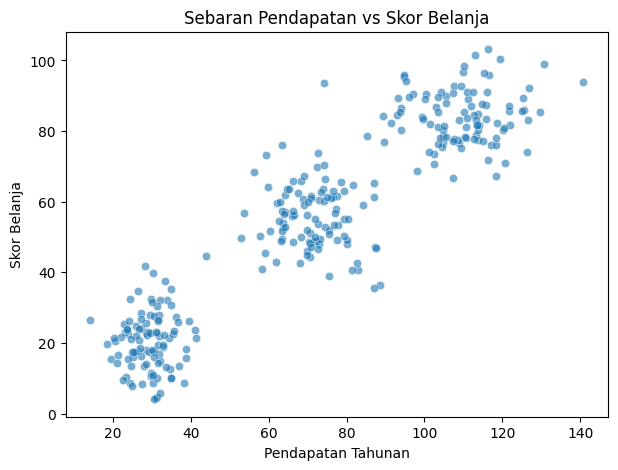

In [9]:
# Visualisasi sebaran pendapatan dan skor belanja

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="pendapatan_tahunan",
    y="skor_belanja",
    alpha=0.6
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.xlabel("Pendapatan Tahunan")
plt.ylabel("Skor Belanja")
plt.show()

In [10]:
# Pilih fitur numerik untuk clustering

X = df[["pendapatan_tahunan", "skor_belanja"]].values

print("Shape fitur:", X.shape)

Shape fitur: (300, 2)


In [11]:
# Step 6 - Scaling data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling:", X_scaled.mean(axis=0).round(3))
print("Standar deviasi setelah scaling:", X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Standar deviasi setelah scaling: [1. 1.]


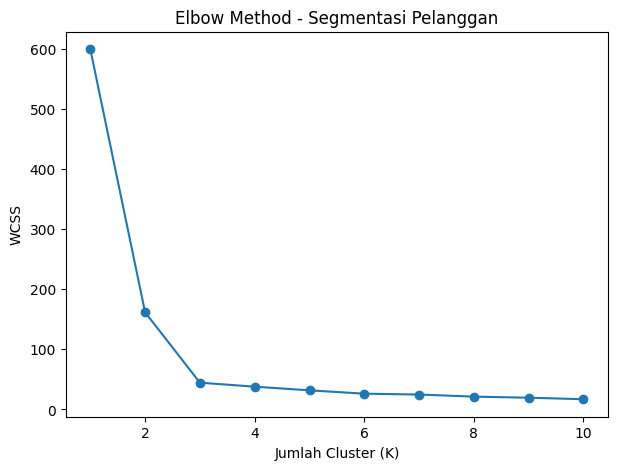

In [12]:
# Metode Elbow untuk menentukan K optimal

wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++"
    )
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method - Segmentasi Pelanggan")
plt.show()

In [13]:
# Menghitung Silhouette Score untuk beberapa nilai K

for k in range(2, 8):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++"
    )
    km.fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    print(f"K={k}: Silhouette Score = {score:.3f}")

K=2: Silhouette Score = 0.634
K=3: Silhouette Score = 0.695
K=4: Silhouette Score = 0.580
K=5: Silhouette Score = 0.491
K=6: Silhouette Score = 0.382
K=7: Silhouette Score = 0.357


In [14]:
# Melatih model K-Means dengan K optimal

model = KMeans(
    n_clusters=3,
    random_state=42,
    init="k-means++"
)

model.fit(X_scaled)

# Simpan label cluster ke dataframe
df["cluster"] = model.labels_

print(f"WCSS akhir: {model.inertia_:.3f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}")

df.head()

WCSS akhir: 44.556
Silhouette Score: 0.695


,pendapatan_tahunan,skor_belanja,usia,gender,cluster
0,32.980285,18.893886,64,P,1
1,33.886131,32.184239,21,P,1
2,28.595080,18.126904,29,L,1
3,39.475277,26.139478,62,L,1
4,27.183154,24.340480,19,L,1


In [15]:
# Ringkasan karakteristik setiap cluster

cluster_summary = df.groupby("cluster")[["pendapatan_tahunan", "skor_belanja", "usia"]].mean().round(2)

cluster_summary

,pendapatan_tahunan,skor_belanja,usia
cluster,,,
0,70.99,55.05,39.16
1,29.31,20.27,42.33
2,109.20,84.08,44.65


In [16]:
# Jumlah pelanggan per cluster

df["cluster"].value_counts().sort_index()

,count
cluster,
0,99
1,100
2,101


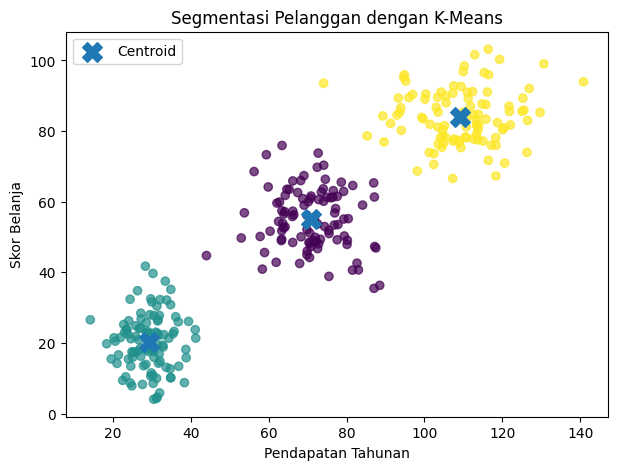

In [17]:
# Visualisasi hasil clustering K-Means

centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroid"
)

plt.xlabel("Pendapatan Tahunan")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan dengan K-Means")
plt.legend()
plt.show()

In [18]:
# Menampilkan ringkasan cluster untuk interpretasi

cluster_summary = df.groupby("cluster")[["pendapatan_tahunan", "skor_belanja"]].mean().round(2)
cluster_summary

,pendapatan_tahunan,skor_belanja
cluster,,
0,70.99,55.05
1,29.31,20.27
2,109.20,84.08


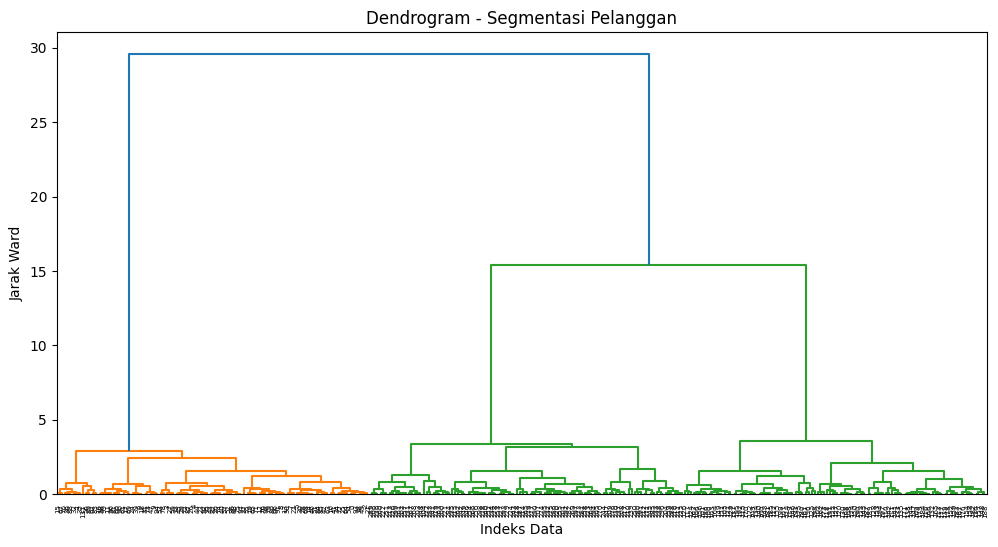

In [19]:
# Hierarchical Clustering dengan Ward Linkage

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z)

plt.title("Dendrogram - Segmentasi Pelanggan")
plt.xlabel("Indeks Data")
plt.ylabel("Jarak Ward")
plt.show()

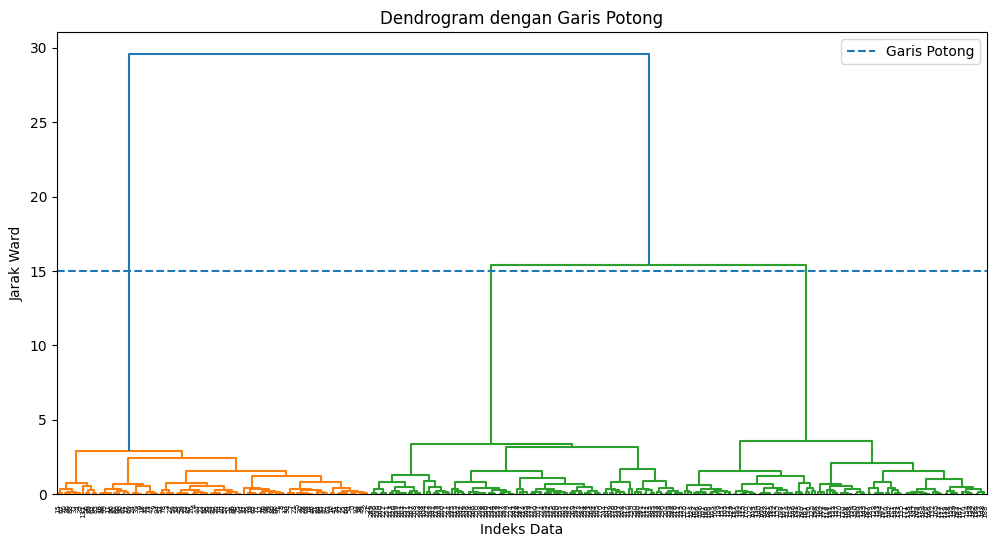

In [20]:
# Dendrogram dengan garis potong

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z)

plt.axhline(y=15, linestyle="--", label="Garis Potong")

plt.title("Dendrogram dengan Garis Potong")
plt.xlabel("Indeks Data")
plt.ylabel("Jarak Ward")
plt.legend()
plt.show()

## Kesimpulan

Pada hands-on Modul 11 ini, materi yang dipelajari adalah **Unsupervised Learning**, khususnya teknik **Clustering** untuk segmentasi pelanggan. Berbeda dengan supervised learning, clustering tidak menggunakan label target. Algoritma berusaha menemukan pola atau kelompok data berdasarkan kemiripan karakteristik antar pelanggan.

Dataset yang digunakan adalah dataset sintetis pelanggan dengan fitur utama **pendapatan_tahunan** dan **skor_belanja**. Data ini digunakan untuk mensimulasikan skenario bisnis, yaitu mengelompokkan pelanggan berdasarkan tingkat pendapatan dan perilaku belanja. Sebelum dilakukan clustering, data terlebih dahulu diproses menggunakan **StandardScaler** agar setiap fitur memiliki skala yang setara.

Algoritma utama yang digunakan adalah **K-Means Clustering**. K-Means bekerja dengan menentukan centroid, mengelompokkan data ke centroid terdekat, lalu memperbarui centroid secara berulang hingga konvergen. Untuk menentukan jumlah cluster yang optimal, digunakan **Elbow Method** dengan melihat perubahan nilai WCSS terhadap jumlah cluster. Selain itu, **Silhouette Score** digunakan sebagai pembanding untuk menilai kualitas hasil clustering.

Hasil clustering menunjukkan bahwa data pelanggan dapat dikelompokkan menjadi tiga segmen utama, yaitu pelanggan dengan pendapatan dan skor belanja rendah, menengah, serta tinggi. Segmentasi ini dapat membantu perusahaan memahami karakteristik pelanggan dan menyusun strategi bisnis yang lebih tepat, seperti promosi khusus untuk pelanggan hemat, program loyalitas untuk pelanggan menengah, atau layanan premium untuk pelanggan bernilai tinggi.

Selain K-Means, project ini juga mempelajari **Hierarchical Clustering** menggunakan dendrogram. Dendrogram membantu melihat proses penggabungan cluster secara bertahap dan dapat digunakan sebagai pembanding dalam menentukan jumlah cluster. Secara keseluruhan, hands-on ini menunjukkan bahwa clustering dapat digunakan untuk menemukan pola tersembunyi dalam data tanpa label dan mendukung pengambilan keputusan berbasis data.